# Base Rates and Statistical Properties

## Findings

1. **If you may pick the counting method, 1 in 11 word pairs in the Quran can be made
   "equal."** Checking all 365,085 possible pairs of reasonably frequent words: 33,560 (9.2%)
   have exactly equal counts under at least one of the 10 uniform counting methods (§5).
2. **Even under a single fixed method, equal counts are everywhere**: 8,594 pairs of words
   occur an identical number of times. "Angels = devils = 88" shares its 88 with two unrelated
   words — *mathal* "example" and *faʿala* "to do" (§1).
3. **The widely cited pairs are equal 41% of the time — about 4.5× the random rate.** This
   is the pattern that publication selection produces (the pairs that matched circulated; the
   candidates that did not were not recorded). Selection and design are observationally
   identical here, so the enrichment cannot adjudicate between them (§5.1).
4. **The corpus's word-frequency profile follows the statistical shape characteristic of
   natural language** (Zipf slope −1.10). Most words are rare, so many words share the same
   small count values — that crowding is *why* equalities are abundant (§2).
5. **The failed claims split**: some miss by exactly 1 (jazāʾ/maghfira — plausibly one
   annotation decision away); the famous life/death 145/145 misses by 39 at best — never
   close, under any selection (§3).

**Bottom line: a list of equal word pairs can be assembled from any sufficiently large text
by searching and keeping the matches, so such a list is not, by itself, evidence of anything
beyond the search. The observed equalities require no special explanation — and, equally,
statistics of this kind cannot rule design in or out.**

---

*Context: the claims audit (notebook 04) established which popular numerical claims reproduce
and under which counting method; this notebook establishes whether reproducing is even
surprising. Cross-checking under an independent annotation scheme (QuranMorph) is tracked as
future work.*

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
from src.parser import load_morphology
from src.buckwalter import bw_to_arabic

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 250)

df = load_morphology()
assert len(df) == 77915

lemma_counts = df.LEM.value_counts()
root_counts = df.ROOT.value_counts()
print(f"distinct lemmas: {len(lemma_counts):,}   distinct roots: {len(root_counts):,}")

distinct lemmas: 4,832   distinct roots: 1,642


## 1. Count-collision base rates

A "numerical balance" claim is, mechanically, the observation that two words have equal
counts. The base-rate question: **in a vocabulary this size with this frequency distribution,
how many equal-count pairs exist in total — and how many other words sit at each celebrated
count value?**

`multiplicity(n)` = number of lemmas occurring exactly *n* times. Any multiplicity *k* yields
*k·(k−1)/2* equal-count pairs at that value.

In [2]:
mult = lemma_counts.value_counts().sort_index()      # count value -> number of lemmas with it
root_mult = root_counts.value_counts().sort_index()

hapax = int((lemma_counts == 1).sum())
tail5 = int((lemma_counts <= 5).sum())
print(f"hapax lemmas (count = 1): {hapax} ({hapax/len(lemma_counts):.0%})")
print(f"lemmas with count <= 5 : {tail5} ({tail5/len(lemma_counts):.0%})")

def equal_pairs(counts, min_count):
    m = counts[counts >= min_count].value_counts()
    return int(sum(k * (k - 1) // 2 for k in m))

rows = []
for floor in [1, 5, 10, 20, 50]:
    rows.append({"min count": floor,
                 "lemmas": int((lemma_counts >= floor).sum()),
                 "equal-count lemma pairs": equal_pairs(lemma_counts, floor),
                 "roots": int((root_counts >= floor).sum()),
                 "equal-count root pairs": equal_pairs(root_counts, floor)})
display(pd.DataFrame(rows).set_index("min count"))
print("Equal counts are abundant at every frequency floor — the raw material of the genre.")

hapax lemmas (count = 1): 1994 (41%)
lemmas with count <= 5 : 3588 (74%)


,lemmas,equal-count lemma pairs,roots,equal-count root pairs
min count,,,,
1,4832,2424642,1642,118584
5,1431,45658,833,9643
10,855,8594,594,2817
20,507,1733,411,895
50,227,181,203,106


Equal counts are abundant at every frequency floor — the raw material of the genre.


### 1.1 Who else sits at each celebrated count value?

For every count value behind a "holds" verdict in the claims audit: how many lemmas (or
roots, for root-level holds) share it, and which. A celebrated equality is one draw from
the pool listed here.

In [3]:
def lemmas_at(n, counts=lemma_counts):
    lems = counts[counts == n].index.tolist()
    return ", ".join(f"{l} [{bw_to_arabic(l)}]" for l in lems)

CELEBRATED_LEMMA = [
    (115, "dunya = akhira(F)"), (88, "malak = shaytan"), (25, "Adam = Isa; lisan claim"),
    (114, "rahma"), (12, "shahr singular; usr root"), (24, "rajul = imra'a singular"),
    (332, "qul = qalu"), (21, "shahr lemma"), (45, "iman lemma"),
]
rows = []
for n, claim in CELEBRATED_LEMMA:
    k = int(mult.get(n, 0))
    rows.append({"count": n, "claim using it": claim, "lemmas at this count": k,
                 "possible equal pairs": k * (k - 1) // 2,
                 "who": lemmas_at(n) if k <= 14 else f"({k} lemmas)"})
display(pd.DataFrame(rows).set_index("count"))

CELEBRATED_ROOT = [(50, "naf' = fasad"), (16, "jahr = 'alaniya"), (25, "lisan = maw'iza"),
                   (167, "sayyi'at side"), (234, "maghfira side")]
rows = []
for n, claim in CELEBRATED_ROOT:
    k = int(root_mult.get(n, 0))
    rows.append({"count": n, "claim using it": claim, "roots at this count": k,
                 "possible equal pairs": k * (k - 1) // 2,
                 "who": lemmas_at(n, root_counts) if k <= 14 else f"({k} roots)"})
display(pd.DataFrame(rows).set_index("count"))

,claim using it,lemmas at this count,possible equal pairs,who
count,,,,
115,dunya = akhira(F),1,0,d~unoyaA [دُّنْيَا]
88,malak = shaytan,4,6,"$ayoTa`n [شَيْطَٰن], maval [مَثَل], faEala [فَعَلَ], malak [مَلَك]"
25,Adam = Isa; lisan claim,12,66,"ya$oEuru [يَشْعُرُ], xalaA [خَلَا], m~iyva`q [مِّيثَٰق], A^dam [ا^دَم], EiysaY [عِيسَى..."
114,rahma,1,0,raHomap [رَحْمَة]
12,shahr singular; usr root,50,1225,(50 lemmas)
24,rajul = imra'a singular,13,78,"<iy~aA [إِيَّا], kaAda [كَادَ], TaEaAm [طَعَام], waraA^' [وَرَا^ء], Hay~ [حَيّ], >unva..."
332,qul = qalu,1,0,rasuwl [رَسُول]
21,shahr lemma,19,171,(19 lemmas)
45,iman lemma,7,21,"Sira`T [صِرَٰط], qadiyr [قَدِير], <iyma`n [إِيمَٰن], Hakama [حَكَمَ], >uwliY [أُولِى],..."


,claim using it,roots at this count,possible equal pairs,who
count,,,,
50,naf' = fasad,3,3,"fsd [فسد], Tyb [طيب], nfE [نفع]"
16,jahr = 'alaniya,14,91,"jhr [جهر], Eln [علن], lbb [لبب], xwn [خون], mhd [مهد], HbT [حبط], xbv [خبث], gdw [غدو]..."
25,lisan = maw'iza,13,78,"$ry [شري], Hwl [حول], sqy [سقي], wEZ [وعظ], HDr [حضر], flk [فلك], bTn [بطن], Hdd [حدد]..."
167,sayyi'at side,2,1,"kvr [كثر], swA [سوا]"
234,maghfira side,1,0,gfr [غفر]


### 1.2 The honest summary statistic

The probability-flavored way to say it: pick any two distinct lemmas with count ≥ 10 at
random; how often are they exactly equal? And the multiplicity table shows that *every*
audited equality has company at its count value or nearby. The full multiplicity table is
exported for reuse.

In [4]:
big = lemma_counts[lemma_counts >= 10]
n_pairs_total = len(big) * (len(big) - 1) // 2
n_equal = equal_pairs(lemma_counts, 10)
print(f"lemmas with count >= 10: {len(big)}")
print(f"random pair of them equal exactly: {n_equal:,} / {n_pairs_total:,} = {n_equal/n_pairs_total:.2%}")
print(f"... within +/-1: ", end="")
vals = np.sort(big.values)
within1 = sum(int(((vals >= v - 1) & (vals <= v + 1)).sum()) - 1 for v in vals) // 2
print(f"{within1:,} / {n_pairs_total:,} = {within1/n_pairs_total:.2%}")

out = pd.DataFrame({"count_value": mult.index, "n_lemmas": mult.values})
out["n_equal_pairs"] = out.n_lemmas * (out.n_lemmas - 1) // 2
out.to_csv("../output/count_multiplicity.csv", index=False)
print("\nSaved output/count_multiplicity.csv (full multiplicity table)")

lemmas with count >= 10: 855
random pair of them equal exactly: 8,594 / 365,085 = 2.35%
... within +/-1: 24,067 / 365,085 = 6.59%

Saved output/count_multiplicity.csv (full multiplicity table)


## 2. Zipf fit and tail statistics

Word frequencies in natural language follow Zipf's law: the *r*-th most frequent word has
frequency roughly proportional to 1/*r*^s with s ≈ 1, a straight line of slope −s on a
log-log rank-frequency plot. Two consequences matter here:

- a **heavy tail**: most lemmas are rare, so many lemmas get packed into each small count
  value — which is exactly where count collisions come from;
- a **steep head**: a few function words dominate the token mass.

The fit is descriptive (this corpus behaves like normal language), not evidential.

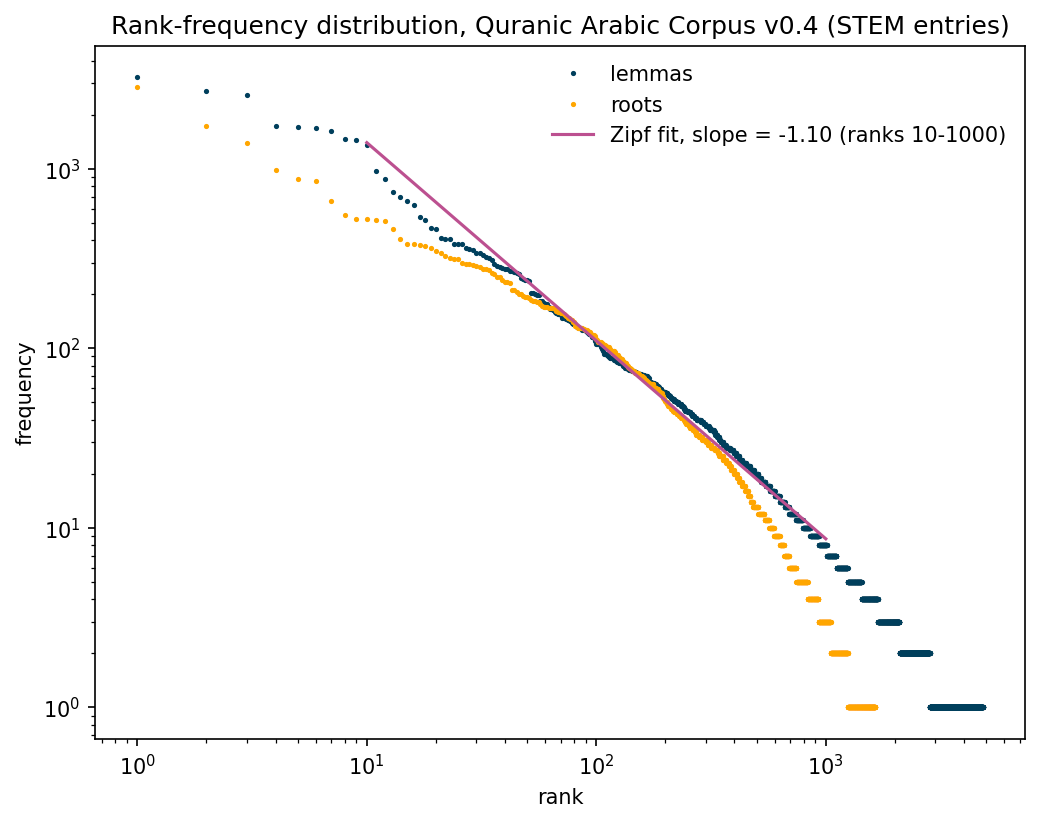

Zipf slope (lemmas, ranks 10-1000): -1.103
top lemmas: {'min [مِن]': 3226, '{ll~ah [ٱللَّه]': 2699, 'maA [مَا]': 2565, 'laA [لَا]': 1738, 'fiY [فِى]': 1701}
top   10 lemmas cover 26.1% of all 77,915 stem tokens
top  100 lemmas cover 57.5% of all 77,915 stem tokens
top 1000 lemmas cover 88.9% of all 77,915 stem tokens
Saved output/zipf_rank_frequency.png


In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

ranks = np.arange(1, len(lemma_counts) + 1)
freqs = lemma_counts.values.astype(float)

# OLS slope on log-log over the mid-range (ranks 10..1000), away from head and quantized tail
sel = (ranks >= 10) & (ranks <= 1000)
slope, intercept = np.polyfit(np.log10(ranks[sel]), np.log10(freqs[sel]), 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(ranks, freqs, ".", color="#003f5c", ms=3, label="lemmas")
rr = np.arange(1, len(root_counts) + 1)
ax.loglog(rr, root_counts.values, ".", color="#ffa600", ms=3, label="roots")
xs = np.array([10, 1000])
ax.loglog(xs, 10 ** (intercept + slope * np.log10(xs)), "-", color="#bc5090", lw=1.5,
          label=f"Zipf fit, slope = {slope:.2f} (ranks 10-1000)")
ax.set_xlabel("rank"); ax.set_ylabel("frequency")
ax.set_title("Rank-frequency distribution, Quranic Arabic Corpus v0.4 (STEM entries)")
ax.legend(frameon=False)
plt.savefig("../output/zipf_rank_frequency.png", dpi=150, bbox_inches="tight")
plt.close()
from IPython.display import Image
display(Image("../output/zipf_rank_frequency.png"))
print(f"Zipf slope (lemmas, ranks 10-1000): {slope:.3f}")

cum = np.cumsum(freqs) / freqs.sum()
top = lemma_counts.head(5)
print("top lemmas:", {f"{l} [{bw_to_arabic(l)}]": int(n) for l, n in top.items()})
for k in [10, 100, 1000]:
    print(f"top {k:>4} lemmas cover {cum[k-1]:.1%} of all 77,915 stem tokens")
print("Saved output/zipf_rank_frequency.png")

## 3. Near-miss sensitivity

For each audited claim: of the methods computed, how many land **exactly** on the claimed
numbers, how many miss by at most 1, by at most 2? (Distance for a pair claim = the larger of
the two sides' misses.) This shows how dense the near-miss space around each celebrated number
is — an exact hit means less when several other selections land within +/-1, and a "does not
hold" verdict is softened or hardened by whether anything came close.

In [6]:
grid = pd.read_csv("../output/claims_audit_grid.csv")

def miss(row):
    d = abs(row.count_a - row.claimed_a)
    if pd.notna(row.claimed_b):
        if pd.isna(row.count_b):
            return np.nan
        d = max(d, abs(row.count_b - row.claimed_b))
    return d

grid["miss"] = grid.apply(miss, axis=1)
g = grid.dropna(subset=["miss"])
near = (g.groupby(["id", "claim"])
          .agg(methods=("miss", "size"),
               exact=("miss", lambda s: int((s == 0).sum())),
               within_1=("miss", lambda s: int((s <= 1).sum())),
               within_2=("miss", lambda s: int((s <= 2).sum())),
               closest_miss=("miss", "min"))
          .reset_index())
near["closest_miss"] = near.closest_miss.astype(int)
display(near.sort_values("id").reset_index(drop=True))
near.to_csv("../output/claims_near_miss.csv", index=False)
print("Saved output/claims_near_miss.csv")

nh = near[near.exact == 0].sort_values("closest_miss")
print("\nClaims with no exact method, by closest miss:")
print(nh[["id", "claim", "closest_miss"]].to_string(index=False))

,id,claim,methods,exact,within_1,within_2,closest_miss
0,C01,Dunya = Akhira,10,5,5,5,0
1,C02,Mala'ika = Shayatin,10,1,1,1,0
2,C03,Hayat = Mawt,11,0,0,0,39
3,C04,Rajul = Imra'a (24),11,1,1,1,0
4,C04b,"Rajul = Imra'a (23, 'chromosome pairs')",11,0,1,1,1
5,C05,Salihat = Sayyi'at,10,0,0,0,13
6,C06,Qul = Qalu,11,1,1,1,0
7,C07,Iblis = isti'adha,8,0,0,2,2
8,C08,Zakat = Baraka,10,0,0,0,17
9,C09,Abrar : Fujjar = 6 : 3,3,1,1,1,0


Saved output/claims_near_miss.csv

Claims with no exact method, by closest miss:
  id                                   claim  closest_miss
C04b Rajul = Imra'a (23, 'chromosome pairs')             1
C17b        Harr = Bard (5, 'summer/winter')             1
 C19                          Nabat = Shajar             1
 C20            Jaza' : Maghfira = 117 : 234             1
 C07                       Iblis = isti'adha             2
 C15                          Musiba = Shukr             2
 C13                       Muhammad = Sharia             3
 C10                    Yusr : Usr = 36 : 12             7
 C05                      Salihat = Sayyi'at            13
 C08                          Zakat = Baraka            17
 C03                            Hayat = Mawt            39
 C12                           Nas = Anbiya'            50


## 4. Sanity checks and deferred work

Pinned invariants (mirrored in `tests/test_base_rates.py`). Deferred analyses are tracked in
the beads issue tracker: `quran-frequencies-dk1` (Monte Carlo null model) and
`quran-frequencies-0bb` (cross-annotation-scheme comparison).

In [7]:
assert len(lemma_counts) == 4832 and len(root_counts) == 1642
assert hapax == 1994
assert int(mult.get(88, 0)) == 4 and int(mult.get(25, 0)) == 12 and int(mult.get(115, 0)) == 1
assert equal_pairs(lemma_counts, 10) == 8594
assert equal_pairs(root_counts, 10) == 2817
jaza = near[near.id == "C20"].iloc[0]
assert jaza.exact == 0 and jaza.closest_miss == 1   # jaza'/maghfira misses 117:234 by exactly 1
print("All base-rate pins verified.")

All base-rate pins verified.


## 5. Null model: how often can a random pair be made equal?

This was planned as a Monte Carlo simulation; the count matrix makes it **exhaustive**
instead (no sampling error). The simulated "claimant": pick any two lemmas (count >= 10),
try every uniform method, and announce a discovery if *any* method makes the two counts
exactly equal (and nonzero). We enumerate all 365,085 pairs under 10 methods (the audit's
grid minus the per-claim ones: variants, exact forms, grammatical selections). Pairs sharing
a root are not counted as equal under root methods (trivially equal by construction).

Then the comparison: the audit's equality-pair claims run through the *identical* test.

In [8]:
from itertools import combinations
from src.parser import load_prefixes, load_pron_suffixes

LOC = pd.Series(list(zip(df.chapter, df.verse, df.word)), index=df.index)
df["is_def"] = LOC.isin(load_prefixes())
df["has_pron"] = LOC.isin(load_pron_suffixes())
df["sg"] = df.NUMBER.isna() | (df.NUMBER == "S")
POS_NOMINAL = ["N", "ADJ", "PN", "T"]

LEMS = lemma_counts[lemma_counts >= 10].index.tolist()
n = len(LEMS)

tab = pd.DataFrame(index=lemma_counts.index)
tab["lemma"] = lemma_counts
tab["singular"] = df[df.sg].groupby("LEM").size().reindex(tab.index, fill_value=0)
tab["dual"] = df[df.NUMBER == "D"].groupby("LEM").size().reindex(tab.index, fill_value=0)
tab["plural"] = df[df.NUMBER == "P"].groupby("LEM").size().reindex(tab.index, fill_value=0)
tab["plural+dual"] = tab.dual + tab.plural
tab["singular definite"] = df[df.sg & df.is_def].groupby("LEM").size().reindex(tab.index, fill_value=0)
tab["lemma, no pron suffix"] = df[~df.has_pron].groupby("LEM").size().reindex(tab.index, fill_value=0)
tab["singular, no pron suffix"] = df[df.sg & ~df.has_pron].groupby("LEM").size().reindex(tab.index, fill_value=0)
lem_root = df.groupby("LEM").ROOT.agg(lambda s: s.dropna().iloc[0] if s.notna().any() else None)
rn = df[df.POS.isin(POS_NOMINAL)].groupby("ROOT").size()
tab["root"] = lem_root.map(root_counts)
tab["root, nominal"] = lem_root.map(rn)

NULL_METHODS = ["lemma", "singular", "dual", "plural", "plural+dual", "singular definite",
                "lemma, no pron suffix", "singular, no pron suffix", "root", "root, nominal"]

def equal_methods(lem_a, lem_b):
    """The uniform methods under which two lemmas' counts are exactly equal and nonzero."""
    out = []
    for m in NULL_METHODS:
        a, b = tab.loc[lem_a, m], tab.loc[lem_b, m]
        if pd.isna(a) or pd.isna(b) or a != b or a == 0:
            continue
        if m.startswith("root") and lem_root[lem_a] == lem_root[lem_b]:
            continue
        out.append(m)
    return out

sub = tab.loc[LEMS]
roots_855 = lem_root.loc[LEMS]
idx = {l: i for i, l in enumerate(LEMS)}
pair_hits = {}
per_method = {}
for m in NULL_METHODS:
    vals = sub[m]
    cnt = 0
    for v, group in vals[vals > 0].groupby(vals[vals > 0]).groups.items():
        lems = list(group)
        for a, b in combinations(lems, 2):
            if m.startswith("root") and roots_855[a] == roots_855[b]:
                continue
            key = (min(idx[a], idx[b]), max(idx[a], idx[b]))
            pair_hits[key] = pair_hits.get(key, 0) + 1
            cnt += 1
    per_method[m] = cnt

total_pairs = n * (n - 1) // 2
union = len(pair_hits)
multi = sum(1 for v in pair_hits.values() if v >= 2)
print(f"{n} lemmas (count >= 10) -> {total_pairs:,} pairs\n")
for m, c in per_method.items():
    print(f"  {m:<26} {c:>7,}  ({c/total_pairs:.2%})")
print(f"\nsome method makes the pair equal: {union:,} / {total_pairs:,} = {union/total_pairs:.1%}")
print(f"equal under >= 2 methods:          {multi:,}  ({multi/total_pairs:.2%})")
NULL_RATE = union / total_pairs

855 lemmas (count >= 10) -> 365,085 pairs

  lemma                        8,594  (2.35%)
  singular                     6,824  (1.87%)
  dual                         1,369  (0.37%)
  plural                       4,284  (1.17%)
  plural+dual                  4,732  (1.30%)
  singular definite            2,030  (0.56%)
  lemma, no pron suffix        7,396  (2.03%)
  singular, no pron suffix     7,520  (2.06%)
  root                         1,509  (0.41%)
  root, nominal                2,217  (0.61%)

some method makes the pair equal: 33,560 / 365,085 = 9.2%
equal under >= 2 methods:          10,404  (2.85%)


### 5.1 The audited pairs under the identical test

For each distinct equality-pair claim, the primary lemmas of both sides go through
`equal_methods` — exactly what a random pair faced above. (Ratio claims, single-number
claims, and qul/qālū — both sides the same lemma, so the pair test is degenerate — are
excluded.)

In [9]:
CLAIM_PAIRS = [
    ("C01", "d~unoyaA", "A^xir"), ("C02", "malak", "$ayoTa`n"), ("C03", "Hayaw`p", "mawot"),
    ("C04", "rajul", "{mora>at"), ("C05", "S~a`liHa`t", "say~i_#aAt"),
    ("C07", "<iboliys", "Eu*o"), ("C08", "zakaw`p", "baraka`t"), ("C11", "nafoE", "fasaAd"),
    ("C12", "n~aAs", "n~abiY~"), ("C13", "muHam~ad", "$ariyEap"), ("C14", "<iyma`n", "kufor"),
    ("C15", "m~uSiybap", "$ukor"), ("C16", "jahor", "EalaAniyap"), ("C17", "Har~", "barod"),
    ("C18", "lisaAn", "m~awoEiZap"), ("C19", "nabaAt", "$ajarap"), ("C21", "A^dam", "EiysaY"),
]
rows = []
for cid, a, b in CLAIM_PAIRS:
    ms = equal_methods(a, b)
    rows.append({"id": cid, "pair": f"{a} / {b}", "equal under": "; ".join(ms) or "—",
                 "hit": bool(ms)})
res = pd.DataFrame(rows)
display(res)
hits = int(res.hit.sum())
print(f"audited pairs with some equalizing method: {hits}/{len(res)} = {hits/len(res):.0%}")
print(f"null rate for a random pair:               {NULL_RATE:.1%}")
print(f"enrichment: ~{hits/len(res)/NULL_RATE:.1f}x")
print(f"\nExpected discoveries per 100 candidate pairs examined at the null rate: {100*NULL_RATE:.0f}")

,id,pair,equal under,hit
0,C01,d~unoyaA / A^xir,—,False
1,C02,malak / $ayoTa`n,lemma,True
2,C03,Hayaw`p / mawot,—,False
3,C04,rajul / {mora>at,singular,True
4,C05,S~a`liHa`t / say~i_#aAt,—,False
5,C07,<iboliys / Eu*o,—,False
6,C08,zakaw`p / baraka`t,—,False
7,C11,nafoE / fasaAd,lemma; singular; root,True
8,C12,n~aAs / n~abiY~,—,False
9,C13,muHam~ad / $ariyEap,—,False


audited pairs with some equalizing method: 7/17 = 41%
null rate for a random pair:               9.2%
enrichment: ~4.5x

Expected discoveries per 100 candidate pairs examined at the null rate: 9


### 5.2 Reading the null model honestly

Three things this establishes, and one it cannot:

1. **Method freedom roughly quadruples the coincidence rate.** A single method makes a random
   pair equal ~0.4–2.4% of the time; the union over 10 methods reaches ~9%. This puts a
   number on the look-elsewhere effect disclosed in notebook 04.
2. **Assembling such a list requires only persistence.** At ~1-in-11 per candidate pair,
   examining a few hundred semantically tempting pairs yields dozens of exact equalities. The
   circulating lists, accumulated over decades by many authors, are consistent with that
   process.
3. **The published pairs are enriched relative to chance (~4.5x): 7/17 vs 9.2%.** That is
   what survivorship looks like: the circulating list *is* the selected survivors of such a
   search. Note the audit credited 10/17 — the extra three (dunya/akhira, ḥarr/bard) hold
   only via per-claim selectors outside the uniform menu (the Akhira gender filter, declared
   variants), which is the per-claim convention point of notebook 04 restated. And well-known
   members of the list (ḥayāt/mawt, nās/anbiyāʾ) fail decisively — indicating the lists
   circulated without being checked against a consistent count.
4. **What it cannot show:** enrichment via selection and enrichment via design are
   observationally identical here. The null model bounds how surprising the genre is
   (not very, given selection); it cannot attribute intent either way.

In [10]:
assert union == 33560 and total_pairs == 365085
assert per_method["lemma"] == 8594          # consistent with section 1
assert hits == 7 and len(res) == 17
print("Null-model pins verified.")

Null-model pins verified.
